### Step 2 — Import Libraries

In [1]:
import fastf1
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

print("Libraries imported successfully!")

Libraries imported successfully!


### Step 3 — Enable FastF1 Cache

In [3]:
import os

cache_path = "../fastf1_cache"

os.makedirs(
    cache_path,
    exist_ok=True
)

fastf1.Cache.enable_cache(
    cache_path
)

print("FastF1 cache enabled successfully!")

FastF1 cache enabled successfully!


### Step 4 — Load an F1 Race Session

Example: 2024 British GP Race

In [4]:
session = fastf1.get_session(
    2024,
    "British",
    "R"
)

session.load()

print("Session loaded successfully!")

core           INFO 	Loading data for British Grand Prix - Race [v3.8.3]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No ca

Session loaded successfully!


### Step 5 — Check Session Information

In [5]:
print(session.event)

print(session.results.head())

RoundNumber                                                       12
Country                                               United Kingdom
Location                                                 Silverstone
OfficialEventName    FORMULA 1 QATAR AIRWAYS BRITISH GRAND PRIX 2024
EventDate                                        2024-07-07 00:00:00
EventName                                         British Grand Prix
EventFormat                                             conventional
Session1                                                  Practice 1
Session1Date                               2024-07-05 12:30:00+01:00
Session1DateUtc                                  2024-07-05 11:30:00
Session2                                                  Practice 2
Session2Date                               2024-07-05 16:00:00+01:00
Session2DateUtc                                  2024-07-05 15:00:00
Session3                                                  Practice 3
Session3Date                      

### Step 6 — Get Driver List

In [6]:
drivers = list(
    session.results["Abbreviation"]
)

drivers

['HAM',
 'VER',
 'NOR',
 'PIA',
 'SAI',
 'HUL',
 'STR',
 'ALO',
 'ALB',
 'TSU',
 'SAR',
 'MAG',
 'RIC',
 'LEC',
 'BOT',
 'OCO',
 'PER',
 'ZHO',
 'RUS',
 'GAS']

### Step 7 — Select Two Drivers for Comparison

In [7]:
driver_1 = "VER"
driver_2 = "NOR"

print(driver_1, driver_2)

VER NOR


### Step 8 — Load Driver Laps

In [8]:
laps_driver_1 = session.laps.pick_driver(
    driver_1
)

laps_driver_2 = session.laps.pick_driver(
    driver_2
)

print("Driver laps loaded successfully!")

Driver laps loaded successfully!


c:\Users\shash\OneDrive\Desktop\F1_AI_Racing\venv\Lib\site-packages\fastf1\core.py:3175: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"


### Step 9 — Get Driver Telemetry

In [9]:
telemetry_1 = laps_driver_1.get_telemetry()

telemetry_2 = laps_driver_2.get_telemetry()

print("Telemetry extracted successfully!")

Telemetry extracted successfully!


### Step 10 — Check Telemetry Data

In [10]:
telemetry_1.head()

,Date,SessionTime,DriverAhead,DistanceToDriverAhead,Time,RPM,Speed,nGear,Throttle,Brake,DRS,Source,Distance,RelativeDistance,Status,X,Y,Z
2,2024-07-07 14:03:12.541,0 days 00:58:15.512000,,0.088889,0 days 00:00:00,10169.825011,0.0,1,17.0,True,1,interpolation,0.019723,6.519062e-08,OnTrack,-1181.912749,1962.109115,1969.999614
3,2024-07-07 14:03:12.660,0 days 00:58:15.631000,,0.088889,0 days 00:00:00.119000,10149.000000,0.0,1,17.0,True,1,car,0.000000,0.000000e+00,OnTrack,-1181.892729,1962.134148,1969.999525
4,2024-07-07 14:03:12.831,0 days 00:58:15.802000,,0.088889,0 days 00:00:00.290000,9707.606085,0.0,1,17.0,True,1,pos,-0.069902,-2.310483e-07,OnTrack,-1182.000000,1962.000000,1970.000000
5,2024-07-07 14:03:12.931,0 days 00:58:15.902000,,0.088889,0 days 00:00:00.390000,9449.481085,0.0,1,17.0,True,1,pos,-0.052200,-1.725383e-07,OnTrack,-1182.000000,1962.000000,1970.000000
6,2024-07-07 14:03:12.980,0 days 00:58:15.951000,14,0.088889,0 days 00:00:00.439000,9323.000000,0.0,1,17.0,False,1,car,0.000000,0.000000e+00,OnTrack,-1181.687114,1962.391281,1969.998614


### Step 11 — Select Important Telemetry Features

In [11]:
telemetry_features_1 = telemetry_1[
    [
        "Speed",
        "Throttle",
        "Brake",
        "RPM",
        "nGear",
        "DRS",
        "Distance"
    ]
]

telemetry_features_2 = telemetry_2[
    [
        "Speed",
        "Throttle",
        "Brake",
        "RPM",
        "nGear",
        "DRS",
        "Distance"
    ]
]


telemetry_features_1.head()

,Speed,Throttle,Brake,RPM,nGear,DRS,Distance
2,0.0,17.0,True,10169.825011,1,1,0.019723
3,0.0,17.0,True,10149.000000,1,1,0.000000
4,0.0,17.0,True,9707.606085,1,1,-0.069902
5,0.0,17.0,True,9449.481085,1,1,-0.052200
6,0.0,17.0,False,9323.000000,1,1,0.000000


### Step 12 — Check Telemetry Statistics

In [12]:
telemetry_features_1.describe()

,Speed,Throttle,RPM,nGear,DRS,Distance
count,37789.000000,37789.000000,37789.000000,37789.000000,37789.000000,37789.000000
mean,220.061362,69.222141,10358.639250,5.452089,0.604700,151161.889330
std,70.432125,40.893493,1463.587664,1.697158,1.371185,85945.409203
min,0.000000,0.000000,3429.000000,1.000000,0.000000,-0.069902
25%,160.000000,31.200000,9963.767422,4.000000,0.000000,77524.821364
50%,243.000000,100.000000,10892.525043,6.000000,0.000000,151911.588300
75%,283.000000,100.000000,11371.000000,7.000000,1.000000,222395.749722
max,327.000000,100.000000,12892.000000,8.000000,14.000000,302535.291454


### Step 13 — Driver Average Speed Comparison

In [13]:
speed_comparison = pd.DataFrame({

    "Driver": [
        driver_1,
        driver_2
    ],

    "Average Speed": [
        telemetry_features_1["Speed"].mean(),
        telemetry_features_2["Speed"].mean()
    ]

})

speed_comparison

,Driver,Average Speed
0,VER,220.061362
1,NOR,219.710260


### Step 14 — Driver Average Throttle Comparison

In [14]:
throttle_comparison = pd.DataFrame({

    "Driver": [
        driver_1,
        driver_2
    ],

    "Average Throttle": [
        telemetry_features_1["Throttle"].mean(),
        telemetry_features_2["Throttle"].mean()
    ]

})

throttle_comparison

,Driver,Average Throttle
0,VER,69.222141
1,NOR,67.185152


### Step 15 — Driver Average Brake Comparison

In [15]:
brake_comparison = pd.DataFrame({

    "Driver": [
        driver_1,
        driver_2
    ],

    "Average Brake": [
        telemetry_features_1["Brake"].mean(),
        telemetry_features_2["Brake"].mean()
    ]

})

brake_comparison

,Driver,Average Brake
0,VER,0.157030
1,NOR,0.155922


### Step 16 — Plot Speed Comparison

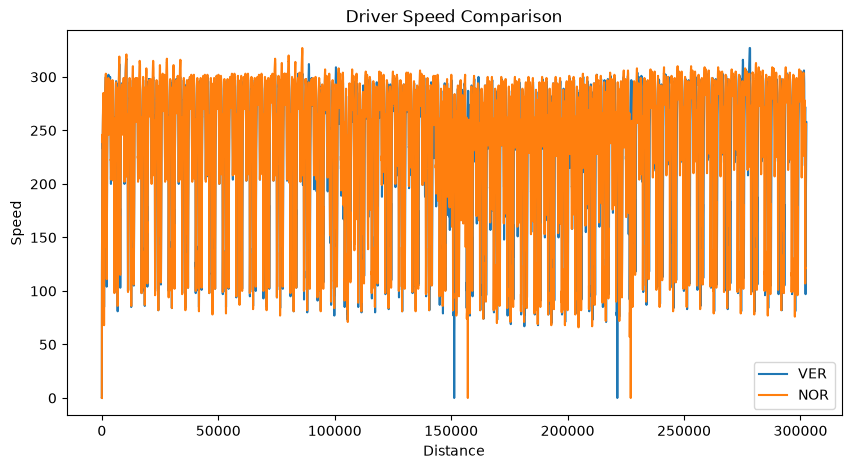

In [16]:
plt.figure(figsize=(10,5))

plt.plot(
    telemetry_features_1["Distance"],
    telemetry_features_1["Speed"],
    label=driver_1
)

plt.plot(
    telemetry_features_2["Distance"],
    telemetry_features_2["Speed"],
    label=driver_2
)

plt.xlabel("Distance")
plt.ylabel("Speed")

plt.title("Driver Speed Comparison")

plt.legend()

plt.show()

### Step 17 — Plot Throttle Comparison

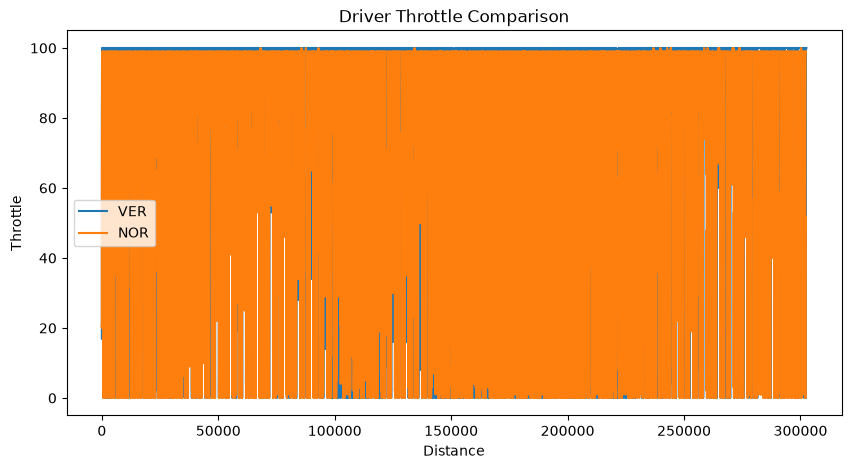

In [17]:
plt.figure(figsize=(10,5))

plt.plot(
    telemetry_features_1["Distance"],
    telemetry_features_1["Throttle"],
    label=driver_1
)

plt.plot(
    telemetry_features_2["Distance"],
    telemetry_features_2["Throttle"],
    label=driver_2
)

plt.xlabel("Distance")
plt.ylabel("Throttle")

plt.title("Driver Throttle Comparison")

plt.legend()

plt.show()

### Step 18 — Plot Braking Comparison

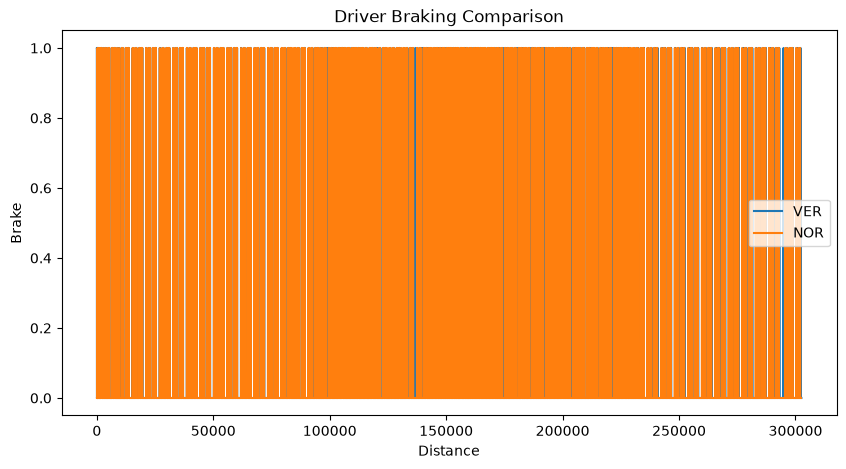

In [18]:
plt.figure(figsize=(10,5))

plt.plot(
    telemetry_features_1["Distance"],
    telemetry_features_1["Brake"],
    label=driver_1
)

plt.plot(
    telemetry_features_2["Distance"],
    telemetry_features_2["Brake"],
    label=driver_2
)

plt.xlabel("Distance")
plt.ylabel("Brake")

plt.title("Driver Braking Comparison")

plt.legend()

plt.show()

### Step 19 — Analyze Lap Time Comparison

In [19]:
lap_time_comparison = pd.DataFrame({

    "Driver": [
        driver_1,
        driver_2
    ],

    "Average Lap Time": [
        laps_driver_1["LapTime"].mean().total_seconds(),
        laps_driver_2["LapTime"].mean().total_seconds()
    ]

})

lap_time_comparison

,Driver,Average Lap Time
0,VER,95.163923
1,NOR,95.280884


### Step 20 — Analyze Gear Usage

In [20]:
gear_usage = pd.DataFrame({

    "Driver": [
        driver_1,
        driver_2
    ],

    "Average Gear": [
        telemetry_features_1["nGear"].mean(),
        telemetry_features_2["nGear"].mean()
    ]

})

gear_usage

,Driver,Average Gear
0,VER,5.452089
1,NOR,5.555467


### Step 21 — Analyze RPM Comparison

In [21]:
rpm_comparison = pd.DataFrame({

    "Driver": [
        driver_1,
        driver_2
    ],

    "Average RPM": [
        telemetry_features_1["RPM"].mean(),
        telemetry_features_2["RPM"].mean()
    ]

})

rpm_comparison

,Driver,Average RPM
0,VER,10358.639250
1,NOR,10276.850029


### Step 22 — Analyze DRS Usage

In [22]:
drs_comparison = pd.DataFrame({

    "Driver": [
        driver_1,
        driver_2
    ],

    "DRS Usage": [
        telemetry_features_1["DRS"].sum(),
        telemetry_features_2["DRS"].sum()
    ]

})

drs_comparison

,Driver,DRS Usage
0,VER,22851
1,NOR,35353


### Step 23 — Create Telemetry Summary

In [23]:
telemetry_summary = pd.DataFrame({

    "Driver": [
        driver_1,
        driver_2
    ],

    "Average Speed": [
        telemetry_features_1["Speed"].mean(),
        telemetry_features_2["Speed"].mean()
    ],

    "Average Throttle": [
        telemetry_features_1["Throttle"].mean(),
        telemetry_features_2["Throttle"].mean()
    ],

    "Average Brake": [
        telemetry_features_1["Brake"].mean(),
        telemetry_features_2["Brake"].mean()
    ],

    "Average RPM": [
        telemetry_features_1["RPM"].mean(),
        telemetry_features_2["RPM"].mean()
    ]

})


telemetry_summary

,Driver,Average Speed,Average Throttle,Average Brake,Average RPM
0,VER,220.061362,69.222141,0.157030,10358.639250
1,NOR,219.710260,67.185152,0.155922,10276.850029


### Step 24 — Save Telemetry Summary

In [25]:
telemetry_summary.to_csv(
    "../../Dataset/fastf1_telemetry_summary.csv",
    index=False
)

print("Telemetry summary saved successfully!")

Telemetry summary saved successfully!


### Step 25 — Save Driver Telemetry Data

In [26]:
telemetry_features_1.to_csv(
    "../../Dataset/driver_1_telemetry.csv",
    index=False
)

telemetry_features_2.to_csv(
    "../../Dataset/driver_2_telemetry.csv",
    index=False
)

print("Driver telemetry saved successfully!")

Driver telemetry saved successfully!


### Step 26 — Final FastF1 Notebook Check

In [27]:
print("FastF1 Telemetry Analysis Completed Successfully! 🏎️")

print("\nDriver 1:", driver_1)
print("Driver 2:", driver_2)

print(
    "\nTelemetry Records:",
    len(telemetry_features_1)
)

print(
    "\nSaved Files:"
)

print("✓ fastf1_telemetry_summary.csv")
print("✓ driver_1_telemetry.csv")
print("✓ driver_2_telemetry.csv")

FastF1 Telemetry Analysis Completed Successfully! 🏎️

Driver 1: VER
Driver 2: NOR

Telemetry Records: 37789

Saved Files:
✓ fastf1_telemetry_summary.csv
✓ driver_1_telemetry.csv
✓ driver_2_telemetry.csv
